# PRAGMATA 中古価格の探索的データ分析（EDA）

メルカリにおける PRAGMATA（PS5版・Nintendo Switch 2版）の中古価格を、
`market_listings_clean` テーブルをもとに分析する。
本ノートブックは読み取り専用であり、スクレイピングやデータベースへの書き込みは一切行わない。

事前に次のパイプラインを実行しておくこと： `scripts/init_db.py` → `scrape_search.py` →
`clean_market_data.py` → `scrape_listing.py` → `clean_market_data.py --build-clean`。

## 1) セットアップ

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# macOS/Linux ship Japanese-capable fonts; use one if present so the JP
# condition labels render instead of tofu boxes. Harmless if unavailable.
for _f in ["Hiragino Sans", "Hiragino Maru Gothic Pro", "YuGothic",
           "Noto Sans CJK JP", "IPAexGothic"]:
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

## 2) データの読み込み

In [2]:
# Resolve the DB whether the notebook runs from notebooks/ or the repo root.
def find_db() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        p = base / "data" / "mercari.sqlite"
        if p.exists():
            return p
    raise FileNotFoundError(
        "data/mercari.sqlite not found — run scripts/init_db.py and the "
        "scrape/clean steps first."
    )

DB_PATH = find_db()
conn = sqlite3.connect(DB_PATH)
df_ps5 = pd.read_sql_query(
    "SELECT * FROM market_listings_clean WHERE game_id = 'pragmata_ps5'", conn
)
conn.close()

print("df_ps5.shape:", df_ps5.shape)
df_ps5.head()

df_ps5.shape: (29, 21)


,id,listing_id,game_id,canonical_title,platform_final,title_raw,description_raw,price_jpy,status_final,condition_raw,...,seller_name_raw,is_standard_edition,is_bundle,is_excluded,exclude_reason,release_date,scraped_at,days_since_release,created_at,updated_at
0,9,m11870632664,pragmata_ps5,PRAGMATA,PS5,PS5 プラグマタ,「PS5 プラグマタ」\n\n#ゲーム #アドベンチャー #PlayStation5 #Pl...,5000.0,on_sale,未使用に近い,...,ゆうさく,1,0,0,None,2026-04-24,2026-06-21T14:38:41.408878+00:00,58.610201,2026-06-21T14:39:52.281385+00:00,2026-06-21T14:40:09.189893+00:00
1,10,m74952264365,pragmata_ps5,PRAGMATA,PS5,PS5 PRAGMATA プラグマタ,Dolby Atmos対応の次世代SFアクションゲームのパッケージ版です。\n\n- 対応機...,4950.0,on_sale,未使用に近い,...,くどう,1,0,0,None,2026-04-24,2026-06-21T14:38:45.666968+00:00,58.610251,2026-06-21T14:39:52.281542+00:00,2026-06-21T14:40:09.190298+00:00
2,11,m92168821815,pragmata_ps5,PRAGMATA,PS5,PS5 PRAGMATA プラグマタ,- ゲームタイトル: PRAGMATA\n- 開発会社: CAPCOM\n- ディスクの状態...,5000.0,on_sale,未使用に近い,...,バオッキー,1,0,0,None,2026-04-24,2026-06-21T14:38:47.800253+00:00,58.610275,2026-06-21T14:39:52.281563+00:00,2026-06-21T14:40:09.190323+00:00
3,12,m61938166793,pragmata_ps5,PRAGMATA,PS5,PS5 PRAGMATA プラグマタ,ハッキングとアクションを融合させた、月面を舞台に繰り広げられる新感覚のSFアクションアドベン...,5000.0,on_sale,目立った傷や汚れなし,...,たま,1,0,0,None,2026-04-24,2026-06-21T14:38:52.056482+00:00,58.610325,2026-06-21T14:39:52.281576+00:00,2026-06-21T14:40:09.190339+00:00
4,13,m54710736635,pragmata_ps5,PRAGMATA,PS5,PS5 プラグマタ,「PS5 プラグマタ」\n定価: ￥ 7264\n\n#ゲーム #アドベンチャー #Play...,5000.0,on_sale,目立った傷や汚れなし,...,nobu,1,0,0,None,2026-04-24,2026-06-21T14:38:54.182446+00:00,58.610349,2026-06-21T14:39:52.281588+00:00,2026-06-21T14:40:09.190352+00:00


## 3) 基本統計量の確認

In [3]:
print("=== price_jpy.describe() ===")
print(df_ps5["price_jpy"].describe())

print("\n=== status_final.value_counts() ===")
print(df_ps5["status_final"].value_counts(dropna=False))

print("\n=== condition_raw.value_counts() ===")
print(df_ps5["condition_raw"].value_counts(dropna=False))

print("\n=== platform_final.value_counts() ===")
print(df_ps5["platform_final"].value_counts(dropna=False))

print("\n=== days_since_release.describe() ===")
print(df_ps5["days_since_release"].describe())

=== price_jpy.describe() ===
count      29.000000
mean     4753.482759
std      1334.446638
min       440.000000
25%      5000.000000
50%      5000.000000
75%      5200.000000
max      6399.000000
Name: price_jpy, dtype: float64

=== status_final.value_counts() ===
status_final
on_sale     28
sold_out     1
Name: count, dtype: int64

=== condition_raw.value_counts() ===
condition_raw
目立った傷や汚れなし    16
未使用に近い        10
新品、未使用         2
やや傷や汚れあり       1
Name: count, dtype: int64

=== platform_final.value_counts() ===
platform_final
PS5        24
unknown     5
Name: count, dtype: int64

=== days_since_release.describe() ===
count    29.000000
mean     58.610552
std       0.000217
min      58.610201
25%      58.610374
50%      58.610548
75%      58.610720
max      58.610919
Name: days_since_release, dtype: float64


## 4) 価格分布の可視化

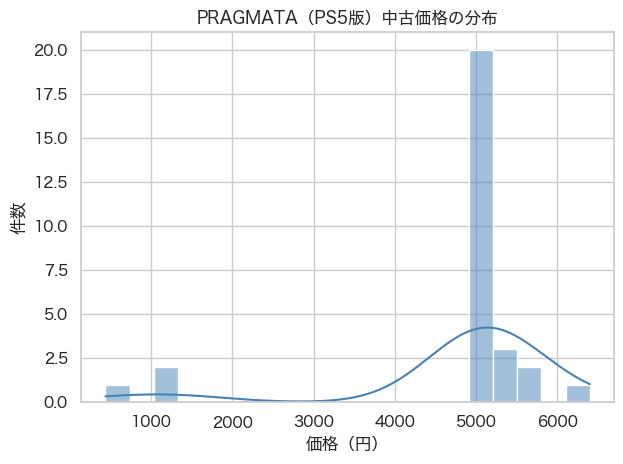

In [4]:
sns.histplot(df_ps5["price_jpy"], bins=20, kde=True, color="steelblue")
plt.title("PRAGMATA（PS5版）中古価格の分布")
plt.xlabel("価格（円）")
plt.ylabel("件数")
plt.tight_layout()
plt.show()

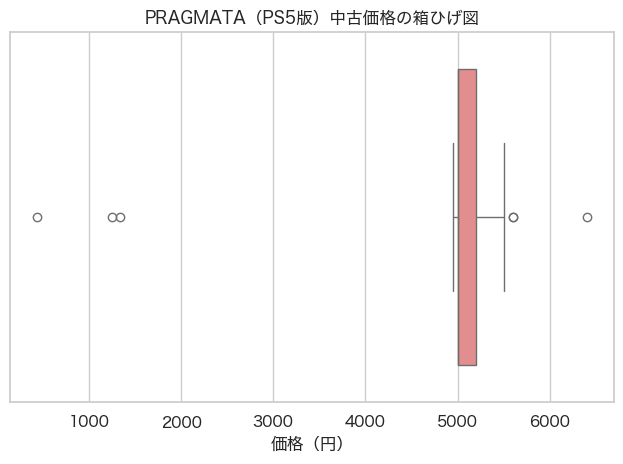

In [5]:
sns.boxplot(x=df_ps5["price_jpy"], color="lightcoral")
plt.title("PRAGMATA（PS5版）中古価格の箱ひげ図")
plt.xlabel("価格（円）")
plt.tight_layout()
plt.show()

## 5) コンディションとステータスの概要

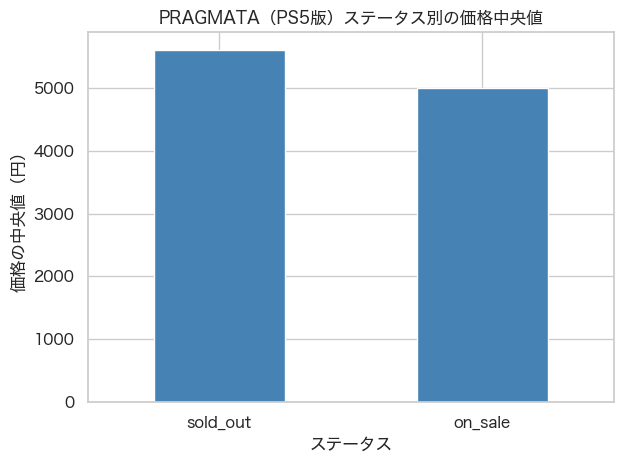

status_final
sold_out    5600.0
on_sale     5000.0
Name: price_jpy, dtype: float64

In [6]:
# Median price by listing status.
med_status = (
    df_ps5.groupby("status_final")["price_jpy"].median().sort_values(ascending=False)
)
ax = med_status.plot(kind="bar", color="steelblue")
ax.set_title("PRAGMATA（PS5版）ステータス別の価格中央値")
ax.set_xlabel("ステータス")
ax.set_ylabel("価格の中央値（円）")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
med_status

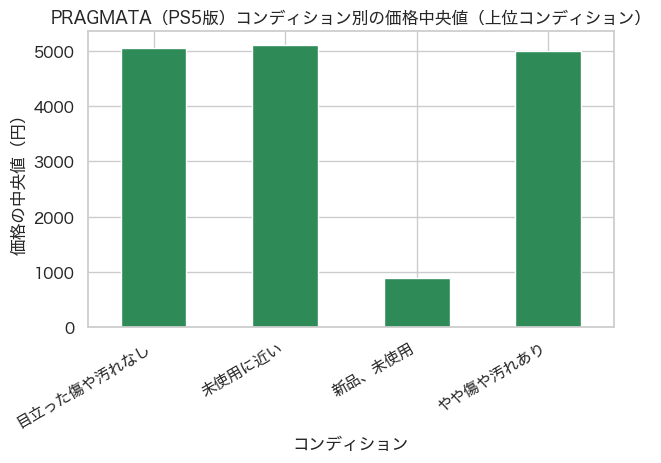

condition_raw
目立った傷や汚れなし    5050.0
未使用に近い        5100.0
新品、未使用         886.5
やや傷や汚れあり      5000.0
Name: price_jpy, dtype: float64

In [7]:
# Median price for the most common conditions only (top 5 by frequency).
top_conditions = df_ps5["condition_raw"].value_counts().head(5).index
sub = df_ps5[df_ps5["condition_raw"].isin(top_conditions)]
med_cond = (
    sub.groupby("condition_raw")["price_jpy"].median().reindex(top_conditions)
)
ax = med_cond.plot(kind="bar", color="seagreen")
ax.set_title("PRAGMATA（PS5版）コンディション別の価格中央値（上位コンディション）")
ax.set_xlabel("コンディション")
ax.set_ylabel("価格の中央値（円）")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
med_cond

## 6) 外れ値の確認

In [8]:
# Flag prices below the 5th or above the 95th percentile for manual review.
lower = df_ps5["price_jpy"].quantile(0.05)
upper = df_ps5["price_jpy"].quantile(0.95)
print(f"lower (5th pct):  {lower:,.0f} JPY")
print(f"upper (95th pct): {upper:,.0f} JPY")

df_outliers = df_ps5[(df_ps5["price_jpy"] < lower) | (df_ps5["price_jpy"] > upper)]
print(f"flagged {len(df_outliers)} of {len(df_ps5)} listings")
df_outliers[["listing_id", "price_jpy", "status_final", "condition_raw", "title_raw"]].head(20)

lower (5th pct):  1,283 JPY
upper (95th pct): 5,600 JPY
flagged 4 of 29 listings


,listing_id,price_jpy,status_final,condition_raw,title_raw
6,m86377366851,440.0,on_sale,新品、未使用,プラグマタ
12,m23054926067,5600.0,sold_out,目立った傷や汚れなし,PS5 ゲームソフト PRAGMATA プラグマタ
24,m68683708290,6399.0,on_sale,未使用に近い,PRAGMATA Nintendo Switch ソフト
28,m96568283840,1250.0,on_sale,未使用に近い,プラグマタ PRAGMATA PS5 ステッカー 3枚入り


## 7) メモと今後の検討課題

**本ノートブックから分かること**

- PRAGMATA（PS5版）の中古価格は **約5,000円** を中心とした狭い範囲に集中している
  （箱ひげ図・ヒストグラムから中心的な価格帯が明確に読み取れる）。
- 数百円程度の **極端に低い価格** がいくつか見られるが、これらはアクセサリーや
  誤マッチ、部分的な出品などによるノイズである可能性が高い。自動的に除外せず、
  外れ値テーブルに表示して目視確認の対象としている。
- 出品の多くは **販売中（`on_sale`）** であり、`sold_out` はごく少数である。
  そのためステータスの内訳は参考になるものの、ステータス別の価格傾向を
  強く結論づけるにはまだ十分なデータ量とは言えない。
- コンディションは少数の生の日本語ラベル（例：`未使用に近い`、
  `目立った傷や汚れなし`）が大半を占める。

**留意点：** 本結果は現時点で詳細を取得できた出品のみを対象としており、
取得時点はおおむね単一であるため `days_since_release` はほぼ一定である。

**今後の検討課題**

- `pragmata_switch2` の詳細データが揃った段階で **PS5 と Switch 2 を比較** する。
- 取得時点が増えた段階で **価格と `days_since_release` の関係** を分析する
  （発売後の価格推移を追跡する）。
- **不自然に高い・低い価格を除外する** ルールを精緻化する
  （価格の下限設定や、外れ値を `title_raw` / `description_raw` と照合するなど）。
- 売却データが蓄積した段階で **`sold_out` と `on_sale` の価格** を分けて分析する
  （売却価格は実際の成約価格に近いと考えられる）。

## PS5 と Switch 2 の比較

`market_listings_clean` をもとに、PRAGMATA の2つのプラットフォームについて、
中古価格（`price_jpy`）と出品ステータス（`status_final`）を並べて比較する。

In [9]:
# Reuse find_db() from the setup section; open a short-lived connection.
conn = sqlite3.connect(find_db())
df_both = pd.read_sql_query(
    """
    SELECT * FROM market_listings_clean
    WHERE game_id IN ('pragmata_ps5', 'pragmata_switch2')
    """,
    conn,
)
conn.close()

platform_map = {"pragmata_ps5": "PS5", "pragmata_switch2": "Switch 2"}
df_both["platform_label"] = df_both["game_id"].map(platform_map)

print("=== rows per game_id ===")
print(df_both["game_id"].value_counts())
print()
df_both[["game_id", "price_jpy", "status_final"]].head()

=== rows per game_id ===
game_id
pragmata_switch2    53
pragmata_ps5        29
Name: count, dtype: int64



,game_id,price_jpy,status_final
0,pragmata_ps5,5000.0,on_sale
1,pragmata_ps5,4950.0,on_sale
2,pragmata_ps5,5000.0,on_sale
3,pragmata_ps5,5000.0,on_sale
4,pragmata_ps5,5000.0,on_sale


In [10]:
# price_jpy summary by platform (count / min / median / max) + status crosstab
print("=== price_jpy by platform ===")
display(df_both.groupby("platform_label")["price_jpy"].describe()[["count", "min", "50%", "max"]])

print("\n=== status_final by platform ===")
display(pd.crosstab(df_both["platform_label"], df_both["status_final"]))

=== price_jpy by platform ===


,count,min,50%,max
platform_label,,,,
PS5,29.0,440.0,5000.0,6399.0
Switch 2,53.0,440.0,6000.0,12000.0



=== status_final by platform ===


status_final,on_sale,sold_out
platform_label,,
PS5,28,1
Switch 2,43,10


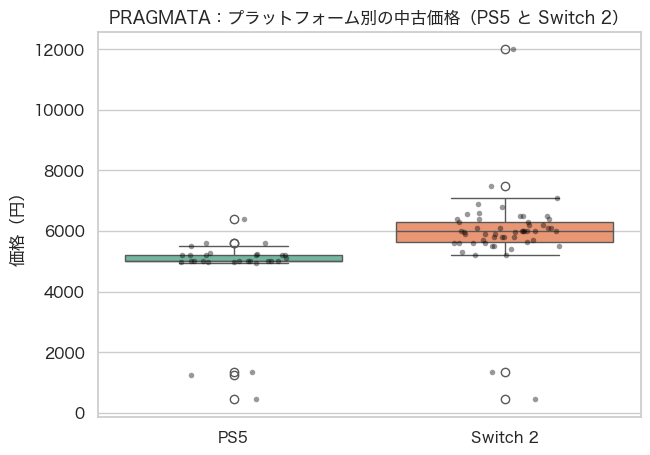

In [11]:
# Price spread by platform: boxplot with jittered points overlaid.
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_both, x="platform_label", y="price_jpy",
            hue="platform_label", palette="Set2", legend=False)
sns.stripplot(data=df_both, x="platform_label", y="price_jpy",
              color="black", alpha=0.4, jitter=0.2, size=4)
plt.title("PRAGMATA：プラットフォーム別の中古価格（PS5 と Switch 2）")
plt.xlabel("")
plt.ylabel("価格（円）")
plt.show()

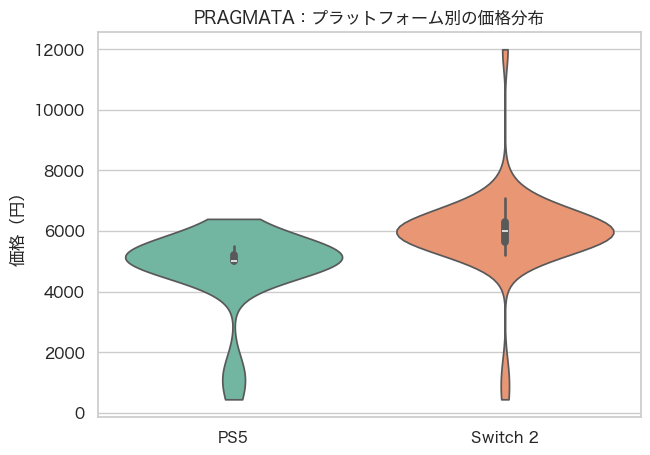

In [12]:
# Distribution shape by platform (violin).
plt.figure(figsize=(7, 5))
sns.violinplot(data=df_both, x="platform_label", y="price_jpy",
               hue="platform_label", palette="Set2", legend=False, cut=0)
plt.title("PRAGMATA：プラットフォーム別の価格分布")
plt.xlabel("")
plt.ylabel("価格（円）")
plt.show()

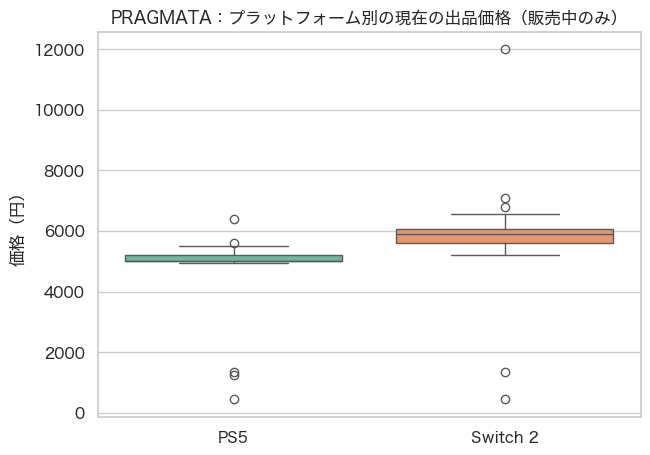

on_sale price_jpy by platform:
                count    min     50%      max
platform_label                               
PS5              28.0  440.0  5000.0   6399.0
Switch 2         43.0  440.0  5900.0  12000.0


In [13]:
# Current asking prices only: compare on_sale listings across platforms.
on_sale = df_both[df_both["status_final"] == "on_sale"]
plt.figure(figsize=(7, 5))
sns.boxplot(data=on_sale, x="platform_label", y="price_jpy",
            hue="platform_label", palette="Set2", legend=False)
plt.title("PRAGMATA：プラットフォーム別の現在の出品価格（販売中のみ）")
plt.xlabel("")
plt.ylabel("価格（円）")
plt.show()

print("on_sale price_jpy by platform:")
print(on_sale.groupby("platform_label")["price_jpy"].describe()[["count", "min", "50%", "max"]])

In [14]:
# Where extreme values sit: 5th / 95th percentile of price_jpy per platform.
pct = df_both.groupby("platform_label")["price_jpy"].quantile([0.05, 0.95]).unstack()
pct.columns = ["p05", "p95"]
print("=== 5th / 95th percentile of price_jpy by platform ===")
print(pct)

=== 5th / 95th percentile of price_jpy by platform ===
                   p05     p95
platform_label                
PS5             1283.2  5599.6
Switch 2        5200.0  6980.0


### メモと解釈

**この比較から分かること（このスナップショット時点）**

- Switch 2 の中古価格の中央値は PS5 より高い（約6,000円 対 約5,000円）。
- Switch 2 は価格の上限がより高く、最大で約12,000円まで広がっている。
- このスナップショットでは、Switch 2 の方が `sold_out` の割合が高い。
- 5パーセンタイルを下回る低価格の外れ値（例：440円）が両プラットフォームに
  見られる。誤マッチや部分的な出品の可能性が高いが、除外せず確認対象として残している。

**限界**

- サンプルサイズが小さく（PS5 は29件、Switch 2 は53件）、差は示唆的であって
  統計的に有意とは言えない。
- すべてのデータが発売からおよそ58日後（約2か月後）の同程度の時点のものであり、
  単一のスナップショットであるため、時系列的な変動はまだ捉えられていない。
- 本分析は記述的な探索的データ分析（EDA）にとどまり、統計的検定・回帰・モデリングは行っていない。